In [ ]:
## understanding your dataset before analysis - EDA 
## Loading the Data 

In [4]:
import pandas as pd 
import json
df = pd.read_json(r"C:\\Users\\pavit\\OneDrive\\Desktop\\course work - AITA\\arxiv-abstracts.jsonl", lines=True)

In [5]:
##size of the dataset
print(df.shape)

(1999486, 11)


In [6]:
## details of the dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1999486 entries, 0 to 1999485
Data columns (total 11 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   id           str   
 1   submitter    str   
 2   authors      str   
 3   title        str   
 4   comments     str   
 5   journal-ref  str   
 6   doi          str   
 7   abstract     str   
 8   report-no    str   
 9   categories   object
 10  versions     object
dtypes: object(2), str(9)
memory usage: 167.8+ MB
None


In [7]:
## fiest few lins of all the columns
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,A fully differential calculation in perturba...,ANL-HEP-PR-07-12,[hep-ph],"[v1, v2]"
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,NaN,NaN,"We describe a new algorithm, the $(k,\ell)$-...",NaN,[math.CO cs.CG],"[v1, v2]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",NaN,NaN,The evolution of Earth-Moon system is descri...,NaN,[physics.gen-ph],"[v1, v2, v3]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,NaN,NaN,We show that a determinant of Stirling cycle...,NaN,[math.CO],[v1]
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,NaN,"Illinois J. Math. 52 (2008) no.2, 681-689",NaN,In this paper we show how to compute the $\L...,NaN,[math.CA math.FA],[v1]


In [8]:
## Inspecting the columns
print(df.columns)

Index(['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi',
       'abstract', 'report-no', 'categories', 'versions'],
      dtype='str')


In [9]:
##checking missing values
df.isnull().sum()

id                   0
submitter        15189
authors              0
title                0
comments        439278
journal-ref    1251755
doi             980309
abstract             0
report-no      1830583
categories           0
versions             0
dtype: int64

In [10]:
## as we can see there are many missing values 
## but the coulums we need don't have any missing values 
## so we will remove the coloums that is not required for the analysis and keep only the one that is needed.
## id, abstract, categories - these are the coloums we need

columns_to_keep = ['id', 'abstract', 'categories']
required_col = df[columns_to_keep]
required_col

,id,abstract,categories
0,0704.0001,A fully differential calculation in perturba...,[hep-ph]
1,0704.0002,"We describe a new algorithm, the $(k,\ell)$-...",[math.CO cs.CG]
2,0704.0003,The evolution of Earth-Moon system is descri...,[physics.gen-ph]
3,0704.0004,We show that a determinant of Stirling cycle...,[math.CO]
4,0704.0005,In this paper we show how to compute the $\L...,[math.CA math.FA]
...,...,...,...
1999481,supr-con/9608008,We report on measurements of the angular dep...,[supr-con cond-mat.supr-con]
1999482,supr-con/9609001,The non-linear microwave surface impedance o...,[supr-con cond-mat.supr-con]
1999483,supr-con/9609002,The vortex contribution to the dc field (H) ...,[supr-con cond-mat.supr-con]
1999484,supr-con/9609003,We show that the density of states in an ani...,[supr-con cond-mat.supr-con]


In [11]:
## as one of the part is splitting corpus into periods - we need to extract the year  from id 
## as there 2 different format for the id 

def extract_year_safe(arxiv_id):
    try:
        # Case 1: New format (0704.0001)
        if arxiv_id[:2].isdigit():
            year = int(arxiv_id[:2])
            return 2000 + year if year < 50 else 1900 + year
        
        # Case 2: Old format (astro-ph/9901234)
        elif '/' in arxiv_id:
            part = arxiv_id.split('/')[-1]
            if part[:2].isdigit():
                year = int(part[:2])
                return 1900 + year if year > 50 else 2000 + year
        
    except:
        return None

In [12]:
## storing the year in a variable 
required_col['year'] = required_col['id'].apply(extract_year_safe)

## checking the year distribution for the split for time period 
min_year = required_col["year"].min()
max_year = required_col["year"].max()

print("Min year:", min_year)
print("Max year:", max_year)

Min year: 1991
Max year: 2021


In [13]:
## as the age gap is 30 years we will be dividing it into 7 to 8 years max 

def get_period(year):
    if 1991 <= year <= 1998:
        return "1991_1998"
    elif 1999 <= year <= 2006:
        return "1999_2006"
    elif 2007 <= year <= 2014:
        return "2007_2014"
    elif 2015 <= year <= 2021:
        return "2015_2021"
    else:
        return "unknown"

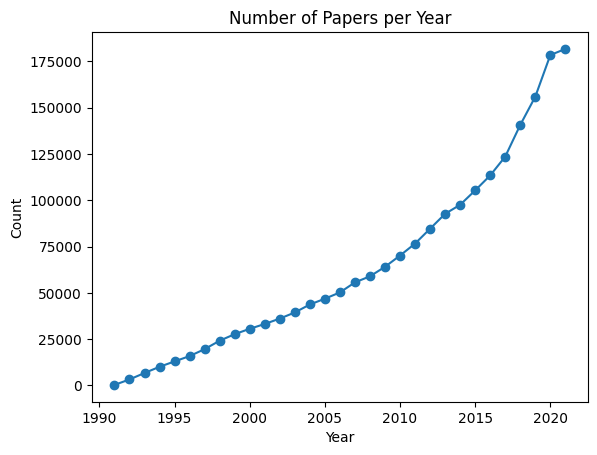

In [15]:
## analysing based ok the year extraction 
## plot to find out the range graph for the count of paper in the per year

import matplotlib.pyplot as plt

year_counts = required_col['year'].value_counts().sort_index()

plt.figure()
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Number of Papers per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

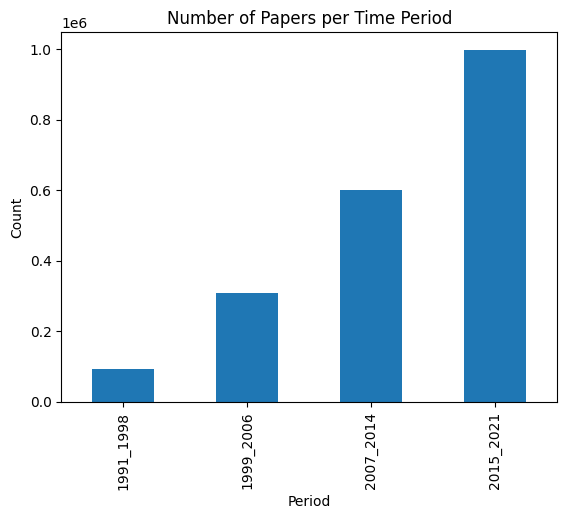

In [16]:
##Papers Per Period

required_col['period'] = required_col['year'].apply(get_period)
period_counts = required_col['period'].value_counts().sort_index()

plt.figure()
period_counts.plot(kind='bar')
plt.title("Number of Papers per Time Period")
plt.xlabel("Period")
plt.ylabel("Count")
plt.show()

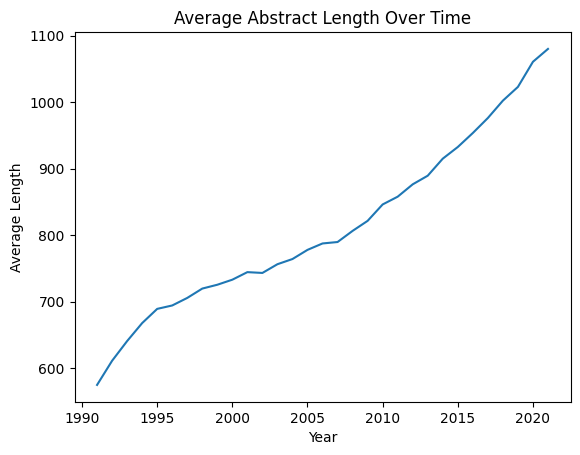

In [17]:
##Abstract Length Over Time

required_col['abstract_length'] = required_col['abstract'].apply(len)

plt.figure()
required_col.groupby('year')['abstract_length'].mean().plot()
plt.title("Average Abstract Length Over Time")
plt.xlabel("Year")
plt.ylabel("Average Length")
plt.show()

<Figure size 640x480 with 0 Axes>

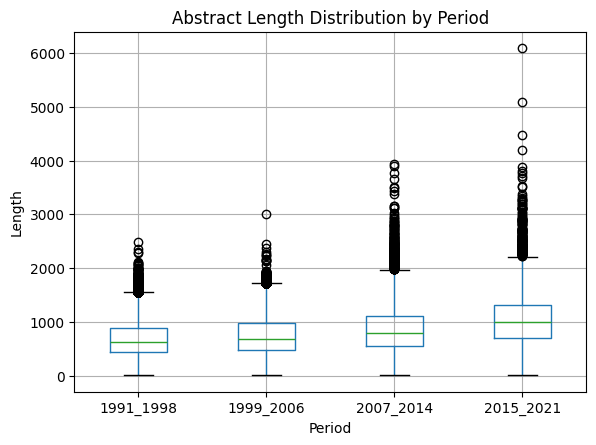

In [18]:
## abstract length by time period   

plt.figure()
required_col.boxplot(column='abstract_length', by='period')
plt.title("Abstract Length Distribution by Period")
plt.suptitle("")
plt.xlabel("Period")
plt.ylabel("Length")
plt.show()

In [19]:
## listing out count of all the unique categories from the category column.
all_categories = [cat for sublist in required_col['categories'] for cat in sublist]
unique_categories = set(all_categories)

print("Total unique categories:", len(unique_categories))

Total unique categories: 68796


In [20]:
##main category 

df_exploded = required_col.explode("categories")

df_exploded["main_category"] = df_exploded["categories"].str.split(".").str[0]
df_exploded["main_category"].value_counts()

main_category
math                                           407994
cs                                             326441
cond-mat                                       271143
astro-ph                                       256094
physics                                        143335
                                                ...  
solv-int alg-geom math                              1
solv-int hep-ph hep-th nlin                         1
solv-int adap-org hep-th nlin                       1
solv-int cond-mat gr-qc hep-lat hep-th nlin         1
supr-con chem-ph cond-mat                           1
Name: count, Length: 1488, dtype: int64

In [21]:
## as there is numtible category we are still dividing it so it will be useful 
## as i am still getting the same numer od sub category now i need to forcefull split it 

def clean_categories(cat):
    result = []
    
    # if list → iterate
    if isinstance(cat, list):
        for item in cat:
            if isinstance(item, str):
                result.extend(item.split())  # split multiple categories
    
    # if string → split directly
    elif isinstance(cat, str):
        result.extend(cat.split())
    
    return result

required_col['categories'] = required_col['categories'].apply(clean_categories)


print(required_col['categories'].iloc[1])

['math.CO', 'cs.CG']


In [22]:
exploded_df = required_col.explode('categories').reset_index(drop=True)

cs_df = exploded_df[
    exploded_df['categories'].str.startswith('cs.')
]
cs_df

,id,abstract,categories,year,period,abstract_length
2,0704.0002,"We describe a new algorithm, the $(k,\ell)$-...",cs.CG,2007,2007_2014,798
73,0704.0046,"In a quantum mechanical model, Diosi, Feldma...",cs.IT,2007,2007_2014,490
75,0704.0047,The intelligent acoustic emission locator is...,cs.NE,2007,2007_2014,1175
76,0704.0047,The intelligent acoustic emission locator is...,cs.AI,2007,2007_2014,1175
80,0704.0050,Part I describes an intelligent acoustic emi...,cs.NE,2007,2007_2014,953
...,...,...,...,...,...,...
3316868,quant-ph/9909094,We prove that quantum computation is polynom...,cs.CC,1999,1999_2006,848
3316905,quant-ph/9910033,Simon as extended by Brassard and H{\o}yer s...,cs.CC,1999,1999_2006,344
3316982,quant-ph/9910087,In a secure bit commitment protocol involvin...,cs.CR,1999,1999_2006,795
3317087,quant-ph/9911043,We define cheat sensitive cryptographic prot...,cs.CR,1999,1999_2006,437


In [23]:
exploded_df = required_col.explode('categories').reset_index(drop=True)
print(exploded_df['categories'].unique())

<StringArray>
[           'hep-ph',           'math.CO',             'cs.CG',
    'physics.gen-ph',           'math.CA',           'math.FA',
 'cond-mat.mes-hall',             'gr-qc', 'cond-mat.mtrl-sci',
          'astro-ph',
 ...
          'alg-geom',          'funct-an',             'q-alg',
            'ao-sci',           'atom-ph',           'chem-ph',
          'plasm-ph',           'mtrl-th',            'cmp-lg',
          'supr-con']
Length: 176, dtype: str


In [24]:
cs_df = exploded_df[
    exploded_df['categories'].str.startswith('cs.')
]

print(cs_df['categories'].unique())

<StringArray>
['cs.CG', 'cs.IT', 'cs.NE', 'cs.AI', 'cs.DS', 'cs.CE', 'cs.MS', 'cs.NA',
 'cs.CC', 'cs.DM', 'cs.LO', 'cs.CR', 'cs.NI', 'cs.LG', 'cs.PF', 'cs.SE',
 'cs.AR', 'cs.SC', 'cs.CY', 'cs.IR', 'cs.CV', 'cs.OH', 'cs.DB', 'cs.DL',
 'cs.HC', 'cs.PL', 'cs.GT', 'cs.DC', 'cs.MA', 'cs.CL', 'cs.MM', 'cs.RO',
 'cs.ET', 'cs.GL', 'cs.FL', 'cs.OS', 'cs.SD', 'cs.GR', 'cs.SY', 'cs.SI']
Length: 40, dtype: str


In [25]:
## now based on the subcategory in cs i am going selected the the paper which is related to AI, ML and NLP
TARGET_SUBCATS = ['cs.AI', 'cs.LG', 'cs.CL']

In [26]:
final_df = exploded_df[
    exploded_df['categories'].isin(TARGET_SUBCATS)
]

print(final_df['categories'].value_counts())
print(final_df.shape)

categories
cs.LG    99417
cs.AI    41758
cs.CL    32221
Name: count, dtype: int64
(173396, 6)


In [28]:
## to make sure we don't have duplicate paper 
final_df = final_df.drop_duplicates(subset=['id'])
print(final_df.shape)
final_df.head()

(144053, 6)


,id,abstract,categories,year,period,abstract_length
76,0704.0047,The intelligent acoustic emission locator is...,cs.AI,2007,2007_2014,1175
81,0704.0050,Part I describes an intelligent acoustic emi...,cs.AI,2007,2007_2014,953
453,0704.0304,This paper discusses the benefits of describ...,cs.AI,2007,2007_2014,793
1019,0704.0671,The problem of statistical learning is to co...,cs.LG,2007,2007_2014,985
1441,0704.0954,"In a sensor network, in practice, the commun...",cs.LG,2007,2007_2014,1751


In [29]:
## data balancer checker - to reduce bais 
print(final_df['period'].value_counts())
print(final_df['period'].value_counts(normalize=True))

period
2015_2021    129193
2007_2014     12196
1999_2006      1612
1991_1998      1052
Name: count, dtype: int64
period
2015_2021    0.896844
2007_2014    0.084663
1999_2006    0.011190
1991_1998    0.007303
Name: proportion, dtype: float64


categories,cs.AI,cs.CL,cs.LG
period,,,
1991_1998,0.116920,0.880228,0.002852
1999_2006,0.540943,0.294045,0.165012
2007_2014,0.456133,0.117826,0.426041
2015_2021,0.171581,0.207132,0.621288


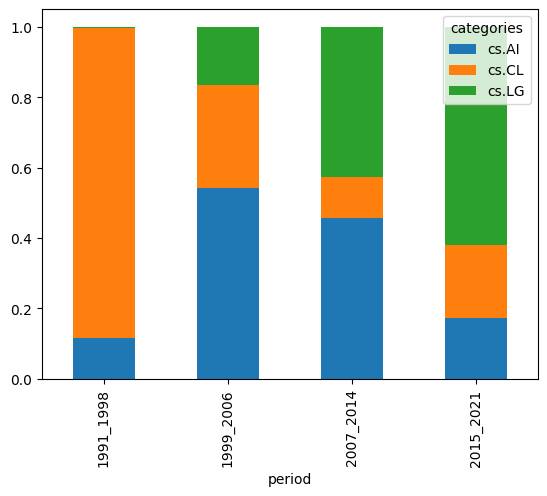

In [30]:
## as we can see the data is not balanced over time we r trying to balance it
trend = pd.crosstab(final_df['period'], final_df['categories'])
trend_norm = trend.div(trend.sum(axis=1), axis=0)
trend_norm.plot(kind='bar', stacked=True)
trend_norm

In [31]:
final_df

,id,abstract,categories,year,period,abstract_length
76,0704.0047,The intelligent acoustic emission locator is...,cs.AI,2007,2007_2014,1175
81,0704.0050,Part I describes an intelligent acoustic emi...,cs.AI,2007,2007_2014,953
453,0704.0304,This paper discusses the benefits of describ...,cs.AI,2007,2007_2014,793
1019,0704.0671,The problem of statistical learning is to co...,cs.LG,2007,2007_2014,985
1441,0704.0954,"In a sensor network, in practice, the commun...",cs.LG,2007,2007_2014,1751
...,...,...,...,...,...,...
3299179,quant-ph/0309022,Modern approaches to semanic analysis if ref...,cs.CL,2003,1999_2006,380
3303180,quant-ph/0411140,In this article we give several new results ...,cs.LG,2004,1999_2006,1626
3305595,quant-ph/0507231,"In Quantum Physics, a measurement is represe...",cs.AI,2005,1999_2006,547
3309257,quant-ph/0607111,Probability-like parameters appearing in som...,cs.AI,2006,1999_2006,776


In [32]:
## saving the final data to csv file 
## don't run 
final_df.to_csv("ai_ml_nlp_dataset.csv", index=False)